# Sudoku Solver

Description: Given values on certain cells, the algorithm will output the unique solution of the Sudoku provided the unique solution exists. 

Cell ordered <br>
0 &nbsp; 1 &nbsp; 2 &nbsp; 3 <br>
4 &nbsp; 5 &nbsp; 6 &nbsp; 7 <br>
8 &nbsp; 9 &nbsp; 10 11<br>
12 13 14 15<br> 

Cell cooedinate <br>
(0,0) (0,1) (0,2) (0,3) <br>
(1,0) (1,1) (1,2) (1,3) <br>
(2,0) (2,1) (2,2) (2,3) <br>
(3,0) (3,1) (3,2) (3,3) <br>

Qubit ordered <br>
0 &nbsp; 2 &nbsp; 4 &nbsp; 6 <br>
8 &nbsp; 10 12 14<br>
16 18 20 22<br>
24 26 28 30<br>

In [1]:
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister
from qiskit.quantum_info import Statevector, Operator

import matplotlib.pyplot as plt

import numpy as np
import itertools

C:\Users\jerry\AppData\Local\Temp\ipykernel_2288\3189939716.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister


# Enter Puzzle

In [22]:
input_puzzle = "0204341003414123"

In [23]:
# read the puzzle
puzzle_list = [int(char) for char in input_puzzle]

# Convert the list into a 4x4 NumPy array
puzzle_array = np.array(puzzle_list).reshape(4, 4)

# Display the result
print(puzzle_array)

[[0 2 0 4]
 [3 4 1 0]
 [0 3 4 1]
 [4 1 2 3]]


In [24]:
# Find Zero (unknown grids) positions
zero_positions = [tuple(pos) for pos in np.argwhere(puzzle_array == 0)]

print(zero_positions)

# How many qubits for unknow grids
N_qubit = len(zero_positions)*2

[(0, 0), (0, 2), (1, 3), (2, 0)]


In [25]:
# 1. Find the coordinates of '0'
zero_positions = [(i, j) for i, row in enumerate(puzzle_array) for j, val in enumerate(row) if val == 0]

# 2. Use sets to guarantee unique indices (no repetition)
unique_rows = sorted(list(set(i for i, j in zero_positions)))
unique_cols = sorted(list(set(j for i, j in zero_positions)))
unique_blocks = sorted(list(set((i // 2) * 2 + (j // 2) for i, j in zero_positions)))

# --- Helper function to extract sub-block elements ---
def get_block_elements(puzzle_array, block_idx):
    start_row = (block_idx // 2) * 2
    start_col = (block_idx % 2) * 2
    return puzzle_array[start_row:start_row+2, start_col:start_col+2].flatten()

# 3. Map which unknown indices (0th, 1st, 2nd...) fall into each row/col/block
row_unknowns = {r: [] for r in unique_rows}
col_unknowns = {c: [] for c in unique_cols}
block_unknowns = {b: [] for b in unique_blocks}

for idx, (i, j) in enumerate(zero_positions):
    b = (i // 2) * 2 + (j // 2)
    row_unknowns[i].append(idx)
    col_unknowns[j].append(idx)
    if b in block_unknowns:  # Safety check
        block_unknowns[b].append(idx)

# --- Define the master set for a 4x4 Sudoku ---
SUDOKU_SET = {1, 2, 3, 4}

# 4. Generate final outputs combining index, known values, and unknown grid indices
row_output = [
    [r, sorted(list(SUDOKU_SET - set(int(x) for x in puzzle_array[r] if x != 0))), row_unknowns[r]] 
    for r in unique_rows
]

col_output = [
    [c, sorted(list(SUDOKU_SET - set(int(x) for x in puzzle_array[:, c] if x != 0))), col_unknowns[c]] 
    for c in unique_cols
]

block_output = [
    [b, sorted(list(SUDOKU_SET - set(int(x) for x in get_block_elements(puzzle_array, b) if x != 0))), block_unknowns[b]] 
    for b in unique_blocks
]

# 5. Print results
print("Found '0' positions:", zero_positions)
print("\nUnique Rows [Row Index, Known Numbers, Unknown Grid IDs]:")
print(row_output)

print("\nUnique Columns [Column Index, Known Numbers, Unknown Grid IDs]:")
print(col_output)

print("\nUnique Sub-blocks [Block Index, Known Numbers, Unknown Grid IDs]:")
print(block_output)

combined_output = row_output + col_output + block_output

Found '0' positions: [(0, 0), (0, 2), (1, 3), (2, 0)]

Unique Rows [Row Index, Known Numbers, Unknown Grid IDs]:
[[0, [1, 3], [0, 1]], [1, [2], [2]], [2, [2], [3]]]

Unique Columns [Column Index, Known Numbers, Unknown Grid IDs]:
[[0, [1, 2], [0, 3]], [2, [3], [1]], [3, [2], [2]]]

Unique Sub-blocks [Block Index, Known Numbers, Unknown Grid IDs]:
[[0, [1], [0]], [1, [2, 3], [1, 2]], [2, [2], [3]]]


In [26]:
N_check = len(row_output) + len(col_output) + len(block_output)
N_check

9

## Marker Circuit

#### match_gate() 

In [27]:
# complement_4_gate: ( used in "match_gate()" ) 
#    given a number a, know which qubits X gates applied on
#    e.g.: a = 1 (binary:01), then need to add "10" to make it to be "11"
def complement_4_gate( a ):
    template = QuantumCircuit(2, name= f"value_{a}" )
    
    if a == 4:
        template.x([0,1])
    else:
        goal = 3-a
        if goal//2 == 1:
            template.x([1])
        if goal%2 == 1:
            template.x([0])
    
    return template.to_gate()

def match_gate( target ):
    template = QuantumCircuit( len(target) * 2 + 1 , name= f"match-{target}")

    qubit = list( range(0, len(target) * 2 +1, 2))

    # Mapping indices: 
    # 0 ~ len(target) * 2 - 1 -> quantum_register
        # each value -> 2 qubits
    # len(target) * 2 -> ancilla_register

      # run through all permutation of target
    for perm in itertools.permutations( target ):
        for i in range(len(target)):  # correspond value (2i, 2i+1) to perm[i]
            template.append( complement_4_gate( perm[i] ), [2*i, 2*i+1])
            
        template.mcx(list(range(0,len(target) * 2)), len(target) * 2)

        for i in range(len(target)):  # Undo
            template.append( complement_4_gate( perm[i] ).inverse(), [2*i, 2*i+1])  
    
    return template.to_gate()


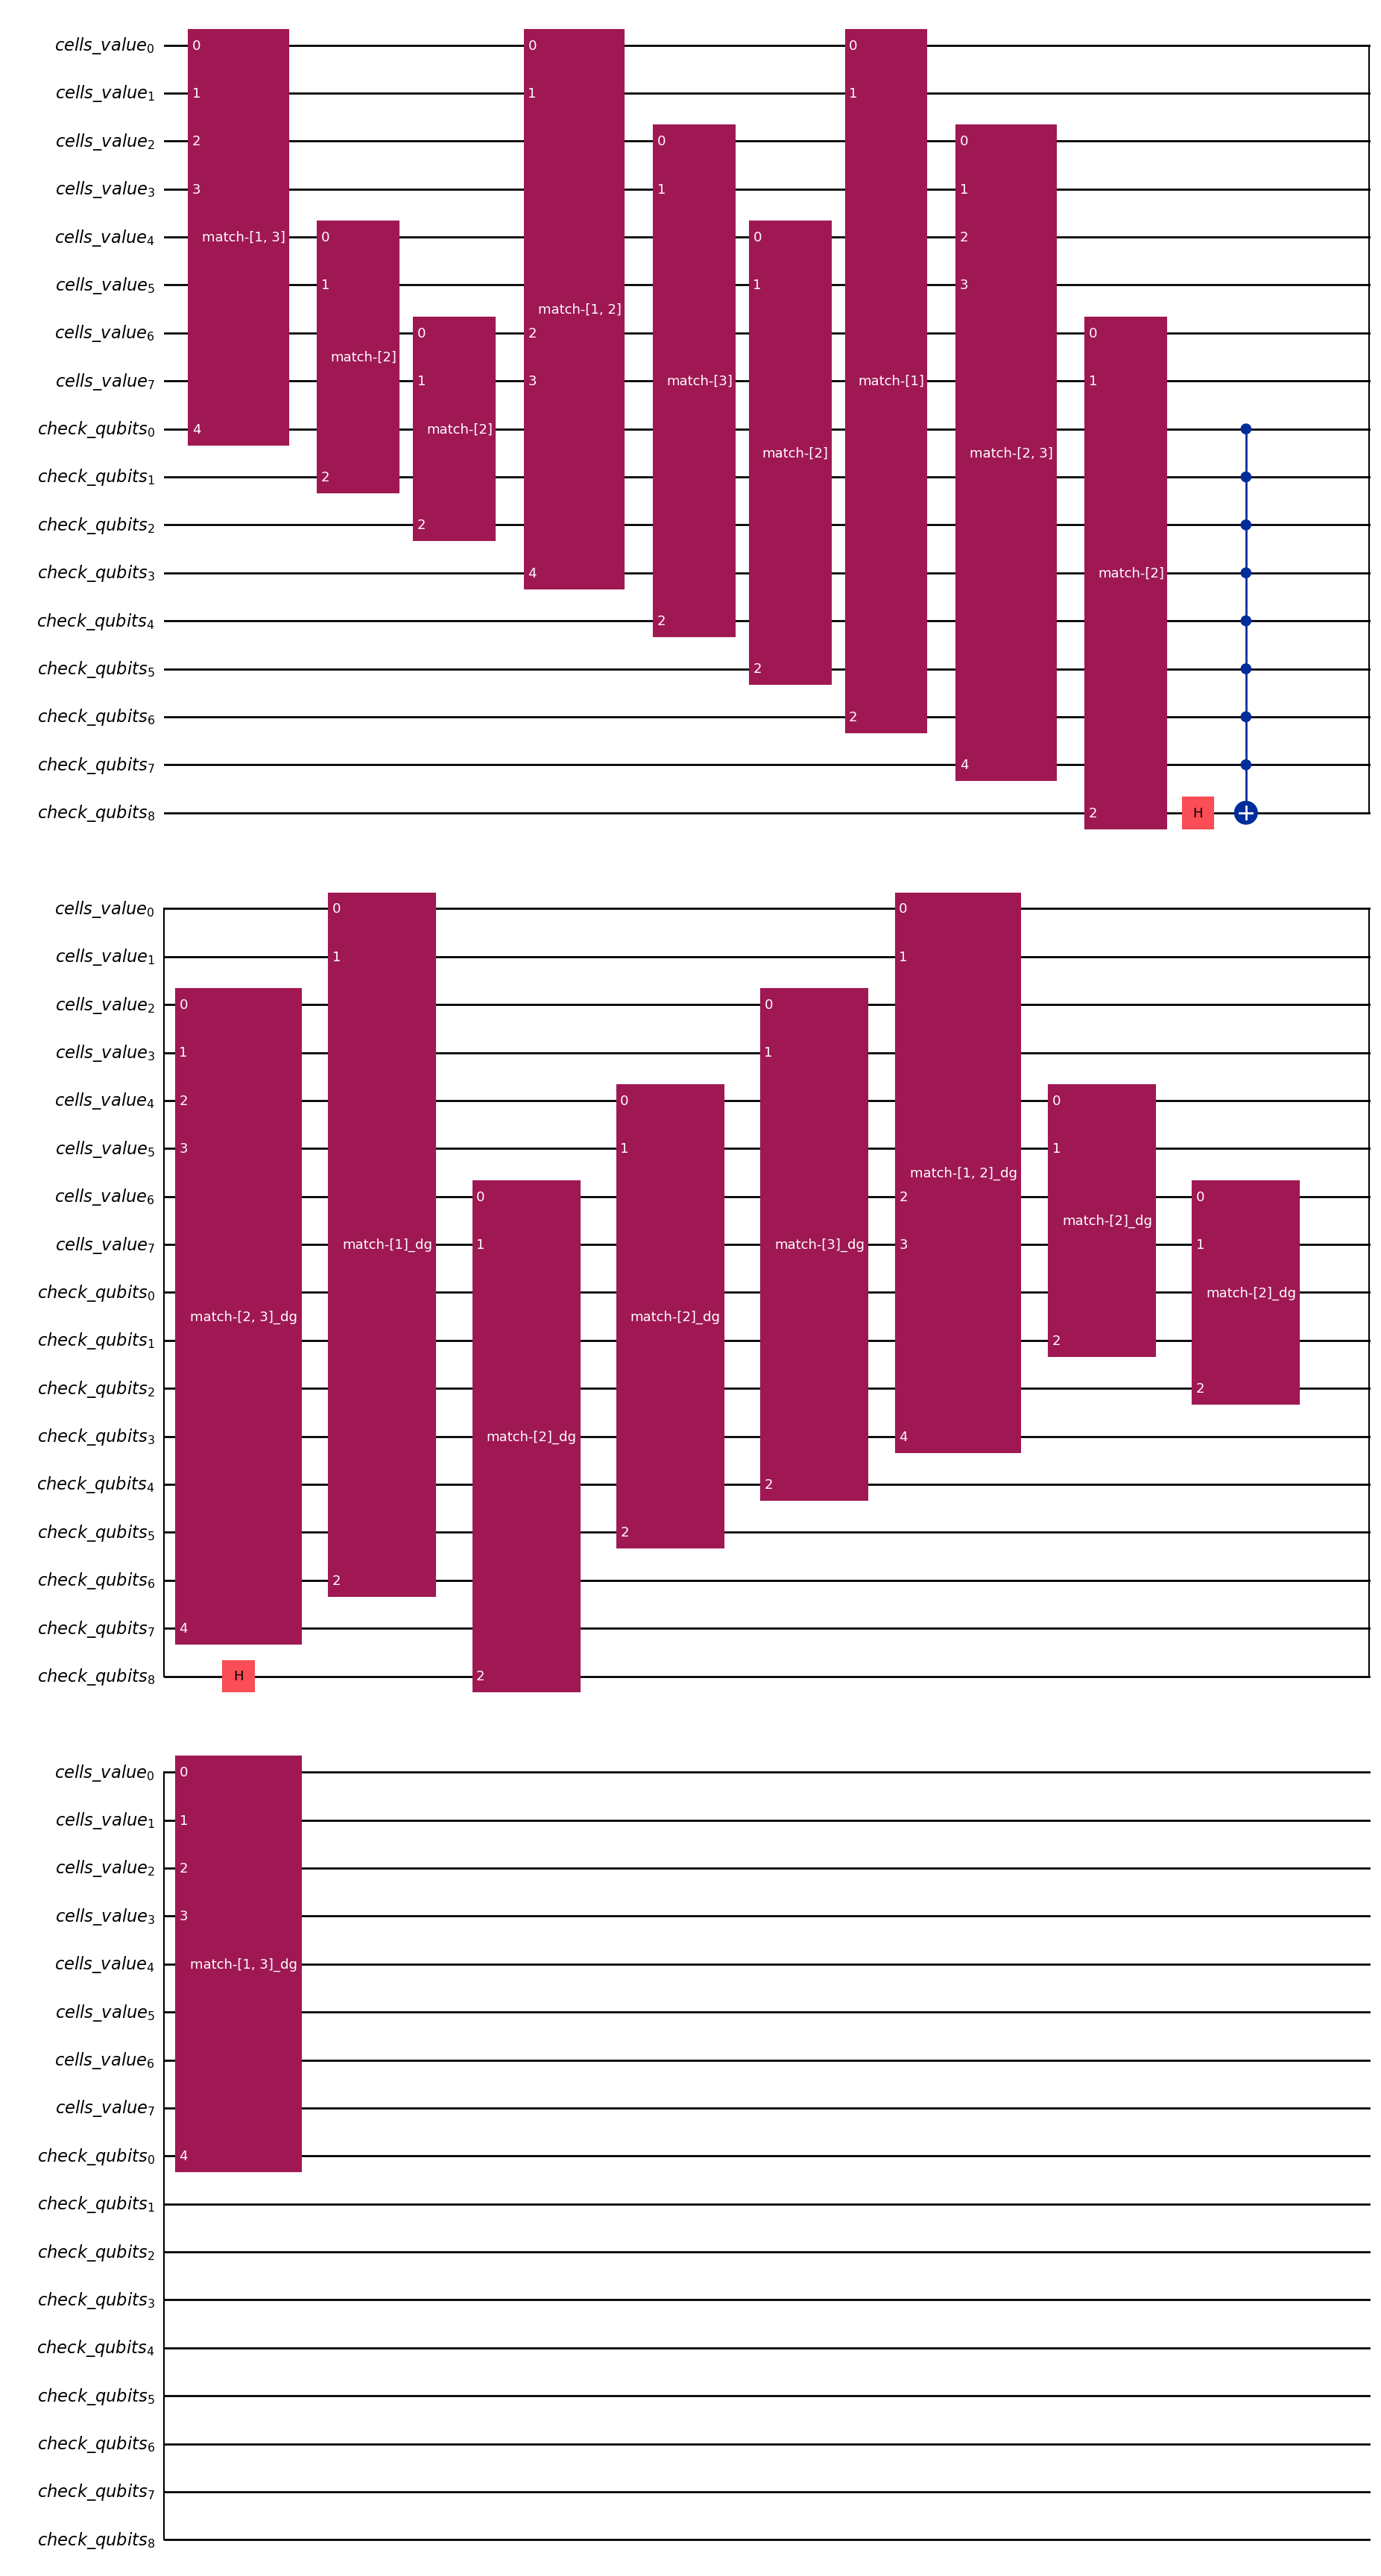

In [28]:
### Marker circuit (using checker gates)

qr = QuantumRegister(size=N_qubit, name="cells_value") #quantum_register
ar = QuantumRegister(size=N_check, name="check_qubits") #ancilla_register

marker_circuit = QuantumCircuit(qr, ar, name="marker" )

    # oracle 
ancilla = 0
for target in combined_output:
    qubit = [qr[result] for x in target[2] for result in (2 * x, 2 * x + 1)]
    qubit.append(ar[ancilla])
    marker_circuit.append( match_gate(target[1]), qubit )
    ancilla += 1
    
# marker_circuit.x(ar[2:])
marker_circuit.h(ar[-1])
marker_circuit.mcx( ar[0:-1], ar[-1] )
marker_circuit.h(ar[-1])
# marker_circuit.x(ar[2:])

# marker_circuit.z(ar[0])

  # Undo
for target in combined_output[::-1]:
    ancilla -= 1
    qubit = [qr[result] for x in target[2] for result in (2 * x, 2 * x + 1)]
    qubit.append(ar[ancilla])
    marker_circuit.append( match_gate(target[1]).inverse(), qubit )


# draw
marker_circuit.draw(output="mpl")

#### Diffuser circuit $S$

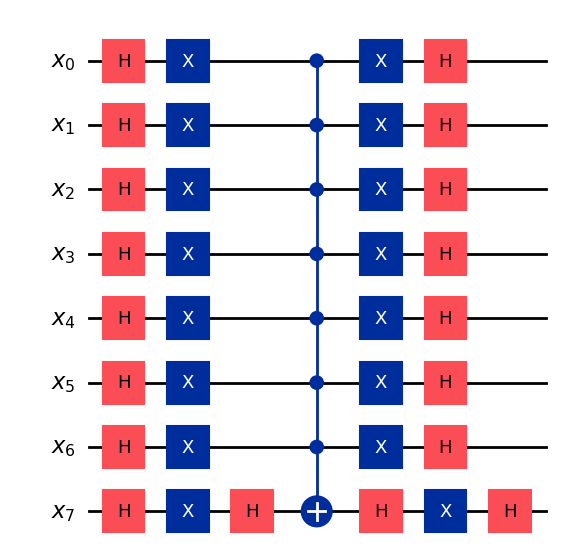

In [29]:
quantum_register = QuantumRegister(size=N_qubit, name="x")

diffuser_circuit = QuantumCircuit(quantum_register, name="diffuser")

### write the rest of the code below
diffuser_circuit.h( quantum_register )

diffuser_circuit.x( quantum_register )
  # mcz gate
diffuser_circuit.h(quantum_register[-1])
diffuser_circuit.mcx( quantum_register[0:-1], quantum_register[-1] )
diffuser_circuit.h(quantum_register[-1])

diffuser_circuit.x( quantum_register )


diffuser_circuit.h( quantum_register )

###

diffuser_circuit.draw(output="mpl")

In [30]:
U = marker_circuit.to_gate()
D = diffuser_circuit.to_gate()

What is the number of iteration, $K$, that you will need?

In [31]:
N = 2**N_qubit

### K = ? (write it as a function of N)
theta = 2 * np.arcsin( N**(-1/2) )
K = int( np.rint( (np.pi / (2*theta) ) - 1/2 ) )
K

12

# Full Grover circuit

Construct the full Grover search circuit and check the probabilities as the end.

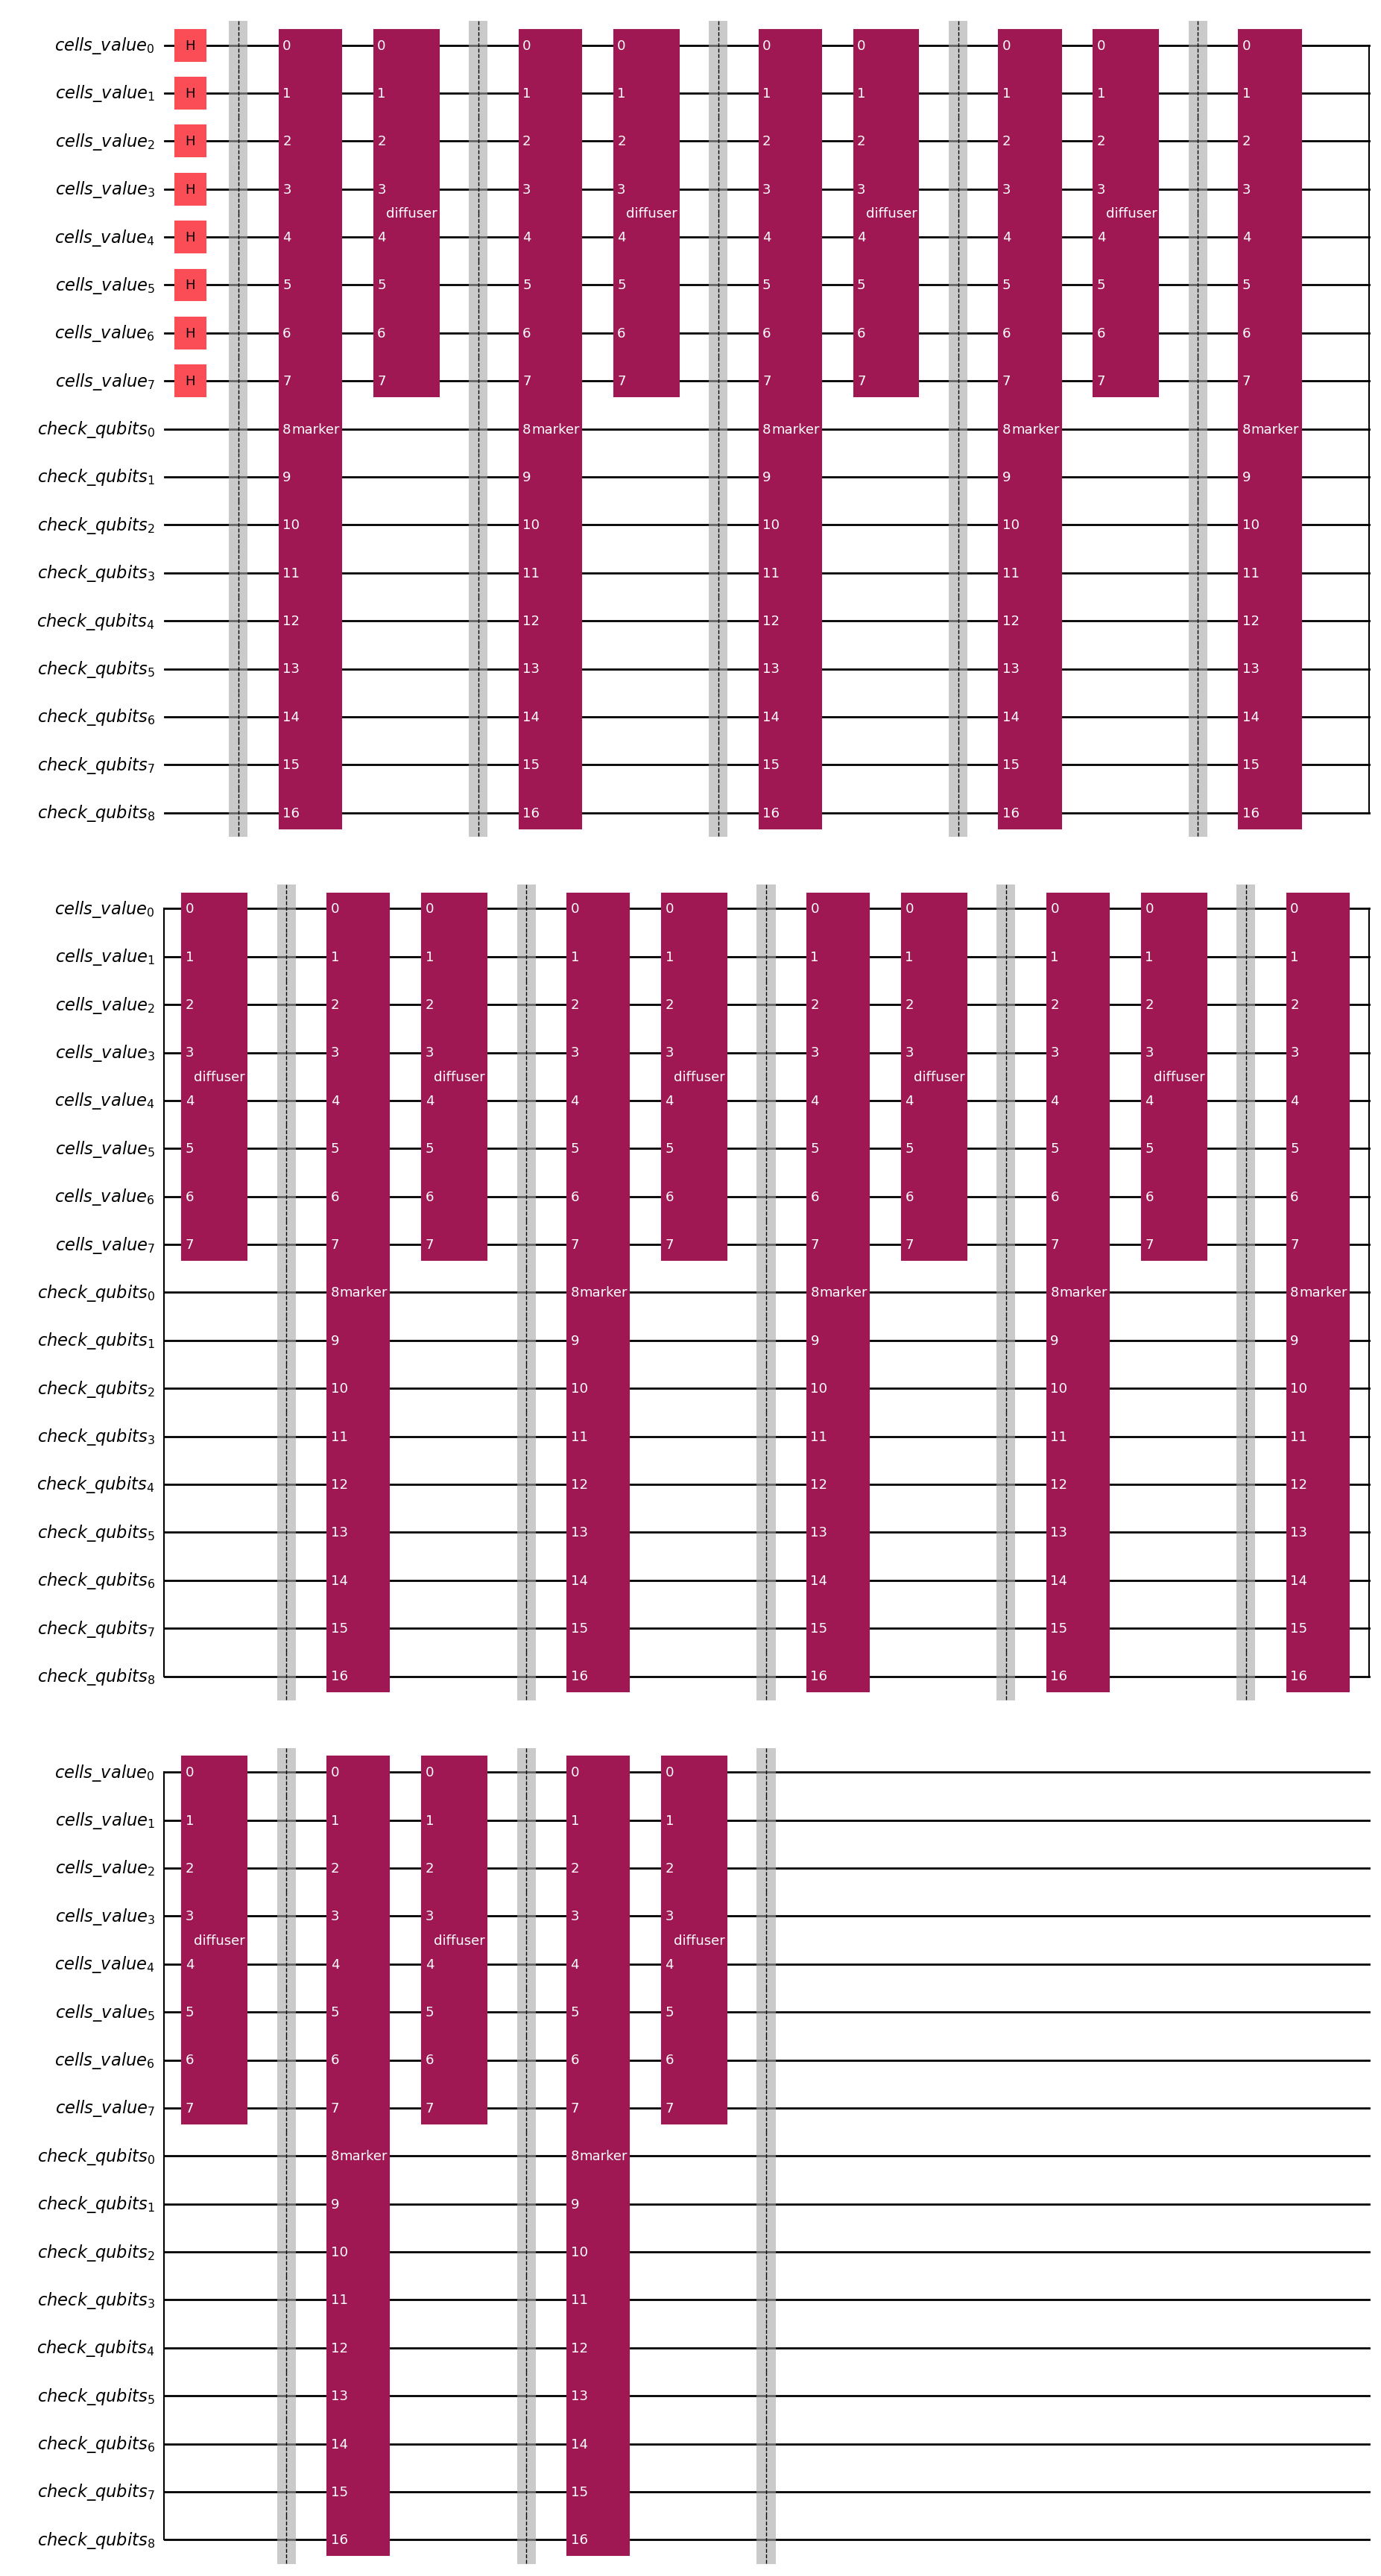

In [32]:
q_register = QuantumRegister(size=N_qubit, name="cells_value")
a_register = QuantumRegister(size=N_check, name="check_qubits")

grover_circuit = QuantumCircuit(q_register, a_register, name="Grover circuit")

### prepare |++...++> state to unknow q_register
grover_circuit.h(q_register)


### write the rest of the code below
    # iterate K times
for i in range(K):
    grover_circuit.barrier()

    grover_circuit.compose(U, inplace=True)
    grover_circuit.compose(D, inplace=True)
    

grover_circuit.barrier()

# grover_circuit.h([q_register[0], q_register[1]])

###

grover_circuit.draw(output="mpl")

In [33]:
psi = Statevector(grover_circuit)
psi.probabilities().argmax()

173

In [35]:
number = psi.probabilities().argmax()

# The ':b' format specifier converts the integer to a binary string
binary_output = f"{number:b}"

print(binary_output)

10101101


In [36]:
# 1. Get the raw binary string
binary_string = f"{number:b}"

# 2. Pad with leading zeros to the exact given even length
binary_string = binary_string.zfill(N_qubit)

# 3. Chop into 2-digit pieces
chopped_binary = [binary_string[i:i+2] for i in range(0, len(binary_string), 2)]

print(f"Number: {number:3} | Binary: {binary_string:8} | Pieces: {chopped_binary}")

Number: 173 | Binary: 10101101 | Pieces: ['10', '10', '11', '01']


In [63]:
# From your previous setup
chopped_binary = chopped_binary[::-1]

# Custom mapping based on your prompt: 
# "11" -> 3, "00" -> 4, "01" -> 1 (and assuming "10" -> 2 if it shows up)
binary_to_sudoku = {
    "01": 1,
    "10": 2,
    "11": 3,
    "00": 4
}

# Match them using zip()
matched_results = []
for idx, (pos, bin_piece) in enumerate(zip(zero_positions, chopped_binary)):
    sudoku_val = binary_to_sudoku[bin_piece]
    matched_results.append({
        "unknown_id": idx,
        "position": pos,
        "binary": bin_piece,
        "value": sudoku_val
    })

# Print the results matching your format
for res in matched_results:
    print(f"{res['unknown_id']}th zero at {res['position']} corresponding to \"{res['binary']}\" (mean {res['value']})")
    
# Print the full solved Sudoku
for res in matched_results:
    puzzle_array[ res['position'] ] = res['value']
print(f"The result has {100*(psi.probabilities()[psi.probabilities().argmax()]):.2f}% to be correct" )
print(f"Solution to Sudoku: \n {puzzle_array}")

0th zero at (0, 0) corresponding to "01" (mean 1)
1th zero at (0, 2) corresponding to "11" (mean 3)
2th zero at (1, 3) corresponding to "10" (mean 2)
3th zero at (2, 0) corresponding to "10" (mean 2)
The result has 99.99% to be correct
Solution to Sudoku: 
 [[1 2 3 4]
 [3 4 1 2]
 [2 3 4 1]
 [4 1 2 3]]
